# Employee Performance Prediction

In [1]:
#Dataset Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

In [2]:
df.describe()

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


In [3]:
df['Performance_Score'].value_counts(normalize = True)*100

Performance_Score
1    20.120
2    20.013
3    19.999
4    19.940
5    19.928
Name: proportion, dtype: float64

## Data Cleaning

In [4]:
df.select_dtypes(include='object').columns

Index(['Department', 'Gender', 'Job_Title', 'Hire_Date', 'Education_Level'], dtype='object')

In [5]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

Department ['IT' 'Finance' 'Customer Support' 'Engineering' 'Marketing' 'HR'
 'Operations' 'Sales' 'Legal']
Gender ['Male' 'Female' 'Other']
Job_Title ['Specialist' 'Developer' 'Analyst' 'Manager' 'Technician' 'Engineer'
 'Consultant']
Hire_Date ['2022-01-19 08:03:05.556036' '2024-04-18 08:03:05.556036'
 '2015-10-26 08:03:05.556036' ... '2015-12-25 08:03:05.556036'
 '2016-02-03 08:03:05.556036' '2017-07-15 08:03:05.556036']
Education_Level ['High School' 'Bachelor' 'Master' 'PhD']


In [6]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [7]:
(df == " ").sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
for col in df.columns:
    if df[col].nunique()==1:
        print(col)

In [10]:
# Target column distribution

df['Performance_Score'].describe()

count    100000.000000
mean          2.995430
std           1.414726
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Performance_Score, dtype: float64

## Exploratory Data Analysis

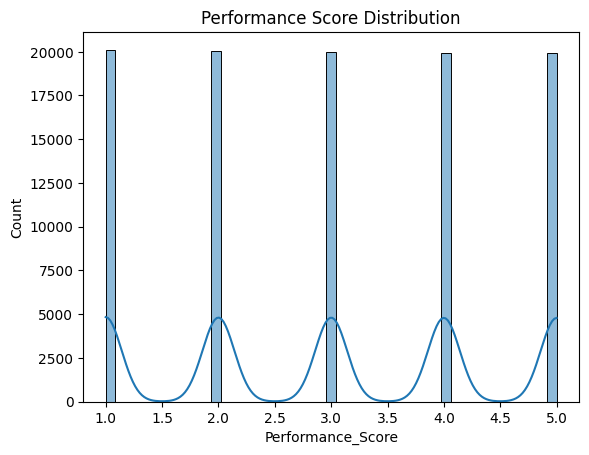

In [11]:
# Distribution Plot

sns.histplot(df['Performance_Score'], kde=True)
plt.title("Performance Score Distribution")
plt.show()

In [12]:
# Skewness

print("Skewness:", df['Performance_Score'].skew())

Skewness: 0.00400848387687358


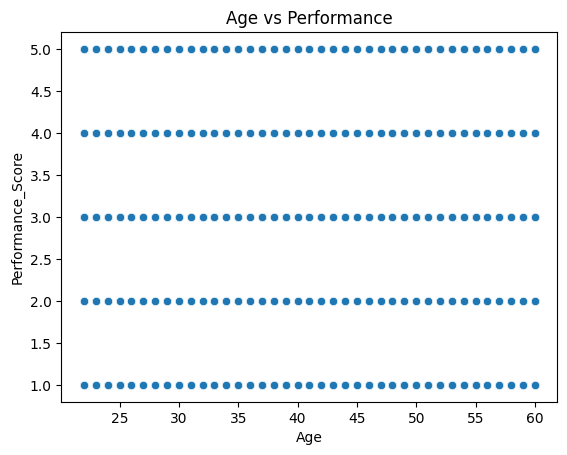

In [13]:
sns.scatterplot(x='Age', y='Performance_Score', data=df)

plt.title("Age vs Performance")
plt.show()

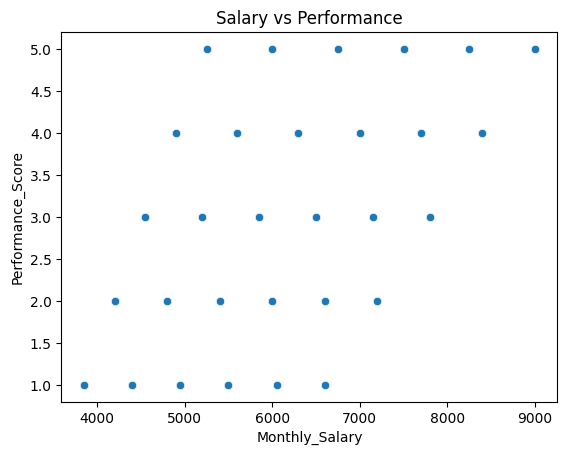

In [14]:
sns.scatterplot(x='Monthly_Salary', y='Performance_Score', data=df)

plt.title("Salary vs Performance")
plt.show()

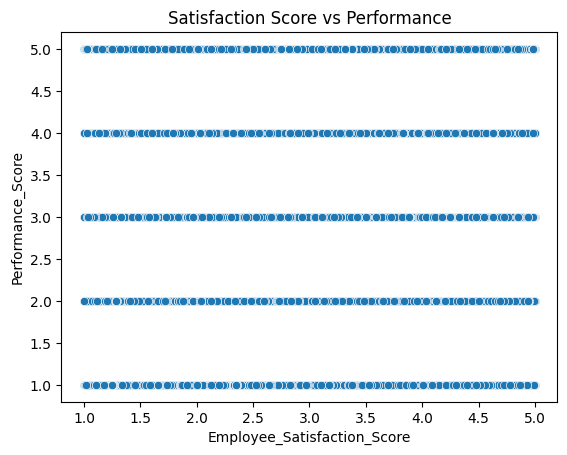

In [15]:
sns.scatterplot(x='Employee_Satisfaction_Score',
                y='Performance_Score',
                data=df)

plt.title("Satisfaction Score vs Performance")
plt.show()

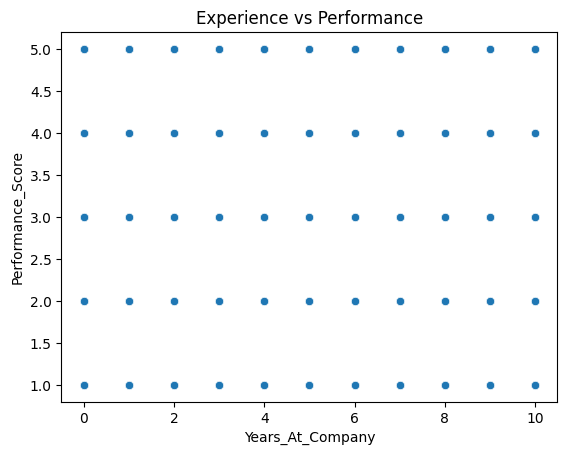

In [16]:
sns.scatterplot(x='Years_At_Company',
                y='Performance_Score',
                data=df)

plt.title("Experience vs Performance")
plt.show()

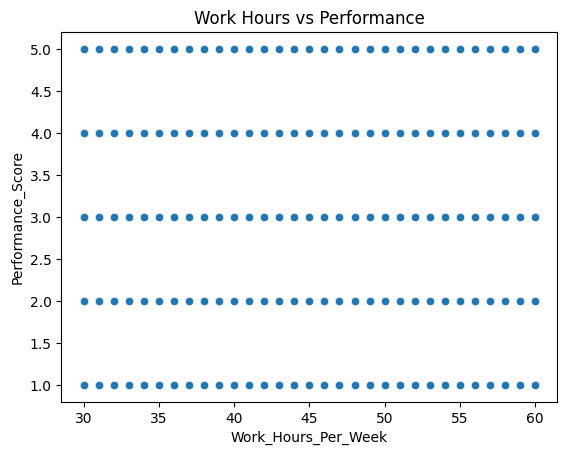

In [17]:
sns.scatterplot(x='Work_Hours_Per_Week',
                y='Performance_Score',
                data=df)

plt.title("Work Hours vs Performance")
plt.show()

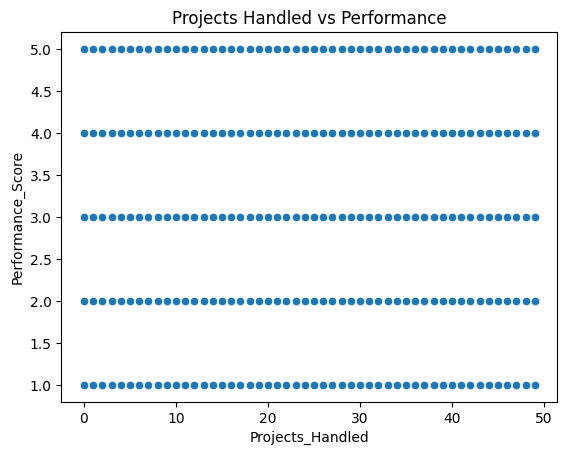

In [18]:
sns.scatterplot(x='Projects_Handled',
                y='Performance_Score',
                data=df)

plt.title("Projects Handled vs Performance")
plt.show()

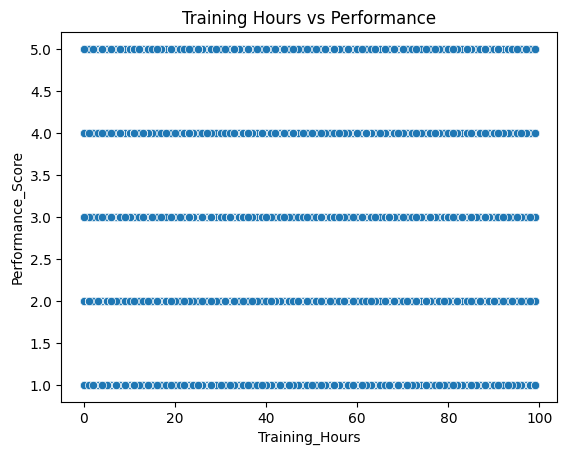

In [19]:
sns.scatterplot(x='Training_Hours',
                y='Performance_Score',
                data=df)

plt.title("Training Hours vs Performance")
plt.show()

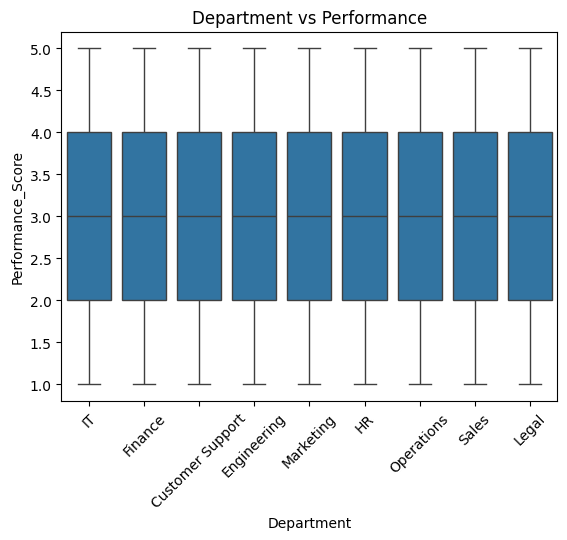

In [20]:
sns.boxplot(x='Department',
            y='Performance_Score',
            data=df)

plt.title("Department vs Performance")
plt.xticks(rotation=45)
plt.show()

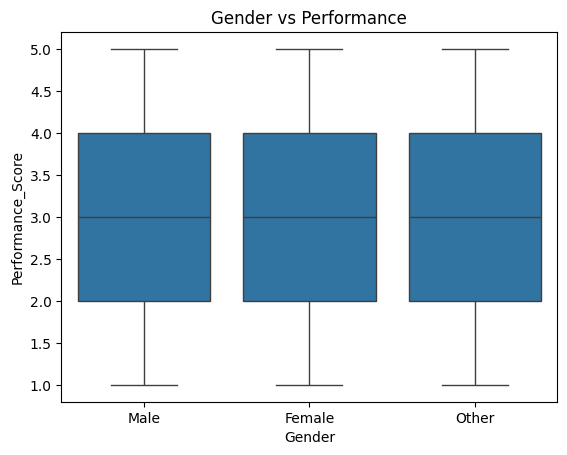

In [21]:
sns.boxplot(x='Gender',
            y='Performance_Score',
            data=df)

plt.title("Gender vs Performance")
plt.show()

## Correlation Analysis

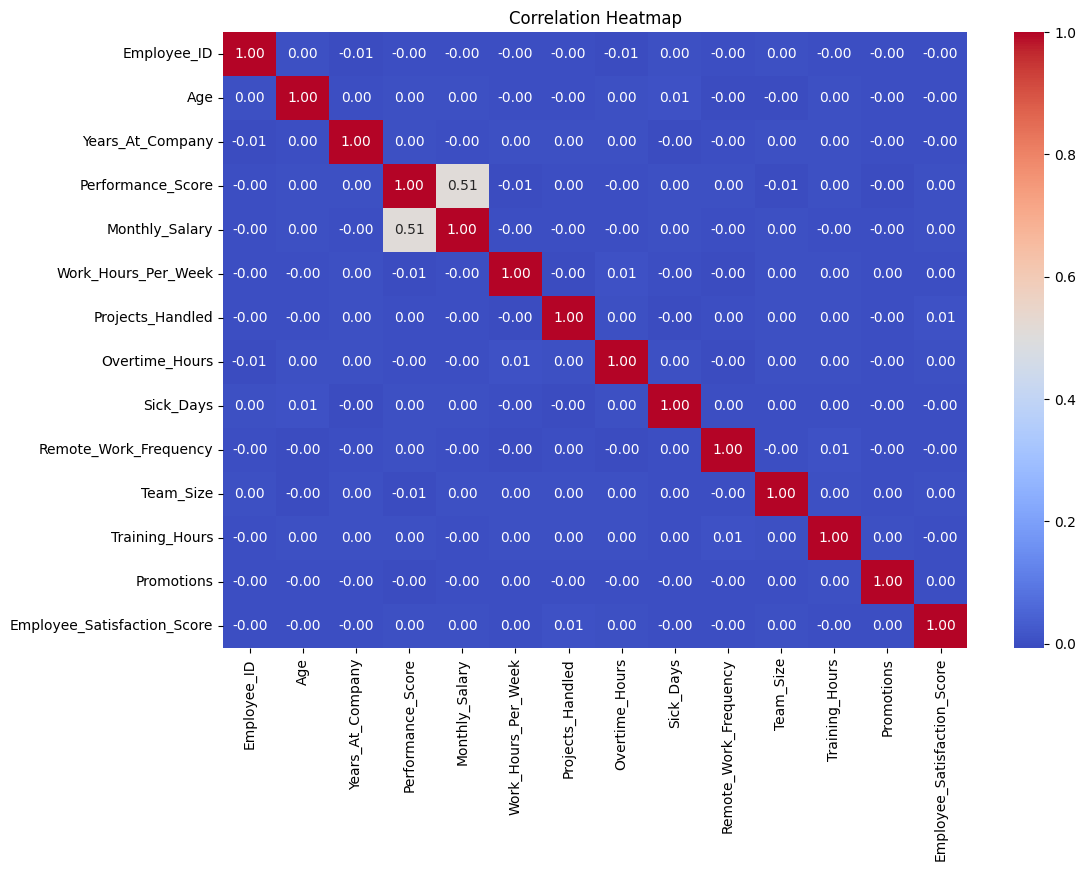

In [22]:
# Select numeric columns

numeric_df = df.select_dtypes(include=np.number)

# Correlation Matrix

corr = numeric_df.corr()

# Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

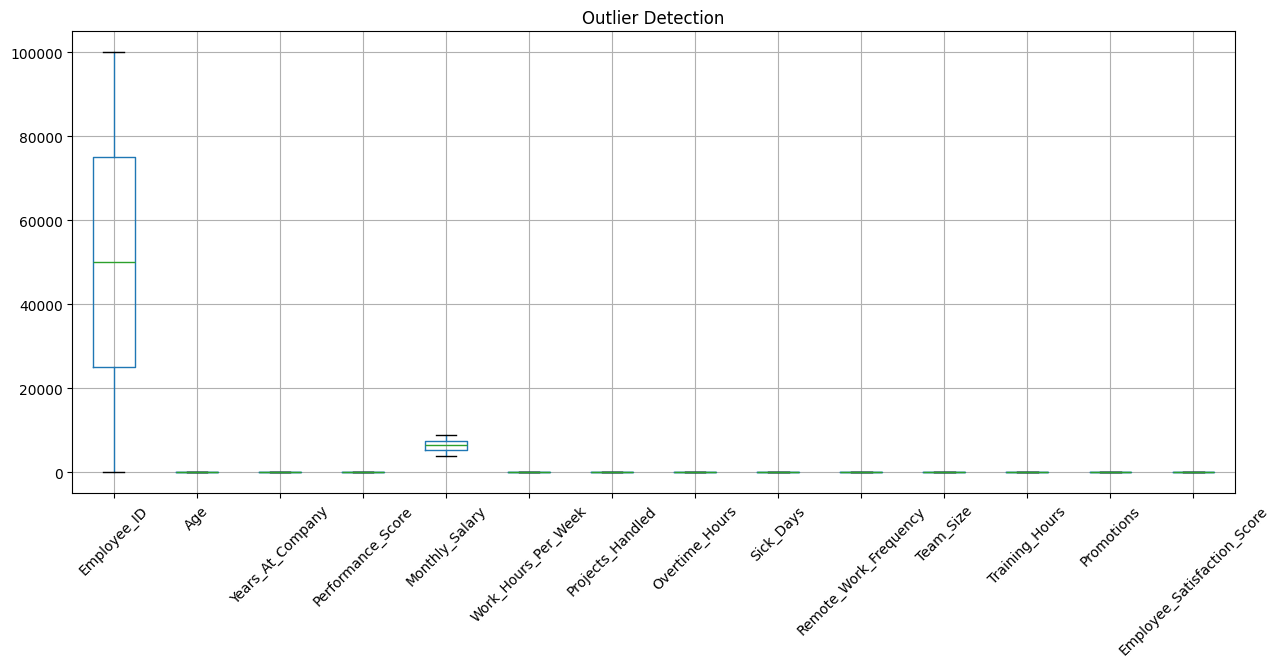

In [23]:
numeric_df.boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

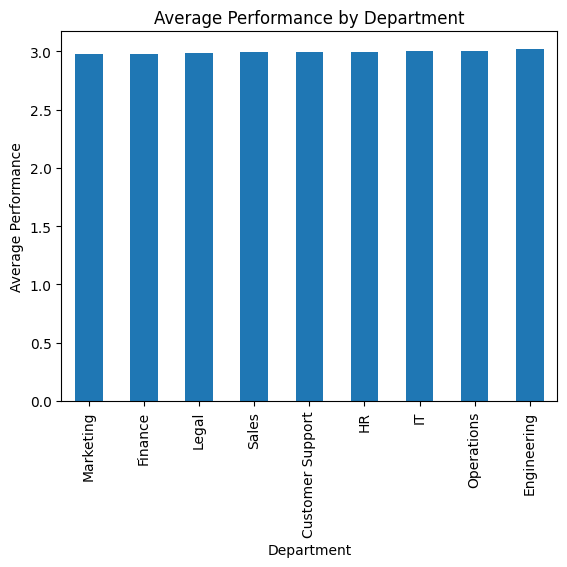

In [24]:
df.groupby('Department')['Performance_Score'].mean().sort_values().plot(kind='bar')

plt.title("Average Performance by Department")
plt.ylabel("Average Performance")
plt.show()

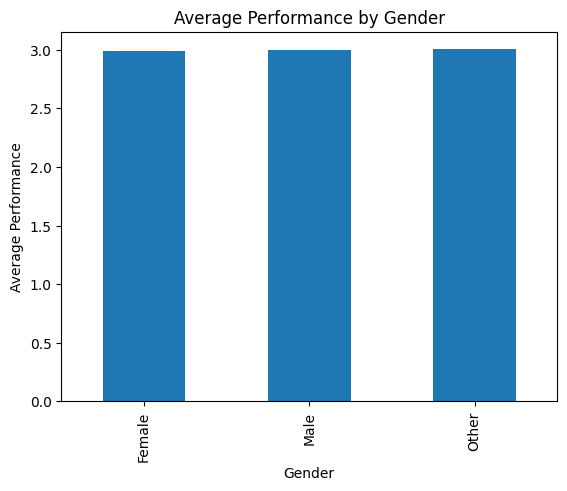

In [25]:
df.groupby('Gender')['Performance_Score'].mean().plot(kind='bar')

plt.title("Average Performance by Gender")
plt.ylabel("Average Performance")
plt.show()

## Feature Engineering

In [26]:
corr = numeric_df.corr()

corr['Performance_Score'].sort_values(ascending=False)

Performance_Score              1.000000
Monthly_Salary                 0.510035
Sick_Days                      0.002994
Training_Hours                 0.002358
Remote_Work_Frequency          0.001733
Employee_Satisfaction_Score    0.001696
Years_At_Company               0.001598
Age                            0.001598
Projects_Handled               0.000640
Overtime_Hours                -0.001312
Employee_ID                   -0.002077
Promotions                    -0.003501
Team_Size                     -0.005174
Work_Hours_Per_Week           -0.005627
Name: Performance_Score, dtype: float64

In [27]:
df = df.drop('Employee_ID', axis=1)

# Check
df.head()

,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [28]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Encode object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Check
df.head()

,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,4,1,55,5,2691,2,1,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,1,29,2,3511,0,1,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,2,1,55,5,414,8,1,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,0,0,48,0,776,7,0,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,1,0,36,0,2511,3,0,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [29]:
X = df.drop('Performance_Score', axis=1)

y = df['Performance_Score']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Building

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(random_state=42)

# Train model
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Feature Importance

In [32]:
# Get feature importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# Sort values
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Show
print(importance)

                        Feature  Importance
7                Monthly_Salary    0.545677
3                     Job_Title    0.126056
16  Employee_Satisfaction_Score    0.033674
4                     Hire_Date    0.033439
14               Training_Hours    0.031146
9              Projects_Handled    0.028289
2                           Age    0.027820
8           Work_Hours_Per_Week    0.026900
10               Overtime_Hours    0.026226
13                    Team_Size    0.023832
11                    Sick_Days    0.021196
0                    Department    0.018947
5              Years_At_Company    0.014004
12        Remote_Work_Frequency    0.013758
6               Education_Level    0.009841
15                   Promotions    0.009096
1                        Gender    0.006911
17                     Resigned    0.003187


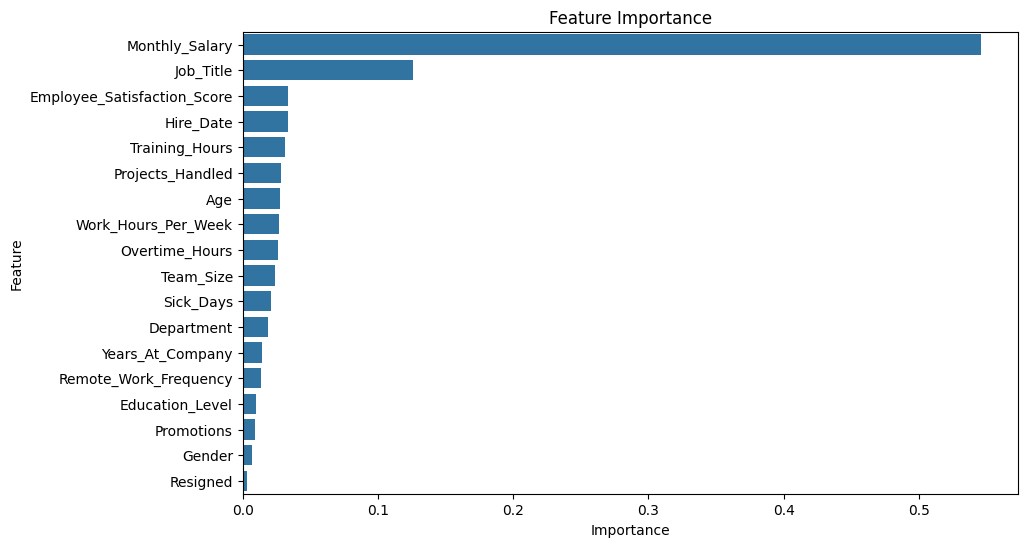

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [34]:
df = df.drop(['Hire_Date', 'Resigned'], axis=1)

# Check remaining columns
df.columns

Index(['Department', 'Gender', 'Age', 'Job_Title', 'Years_At_Company',
       'Education_Level', 'Performance_Score', 'Monthly_Salary',
       'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours',
       'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours',
       'Promotions', 'Employee_Satisfaction_Score'],
      dtype='object')

In [35]:
X = df.drop('Performance_Score', axis=1)

y = df['Performance_Score']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Model Evaluation

In [38]:
y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      4037
           2       1.00      1.00      1.00      4102
           3       1.00      1.00      1.00      3968
           4       1.00      1.00      1.00      3906
           5       1.00      1.00      1.00      3987

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4037    0    0    0    0]
 [   0 4102    0    0    0]
 [   0    0 3968    0    0]
 [   0    0    0 3906    0]
 [   0    0    0    0 3987]]


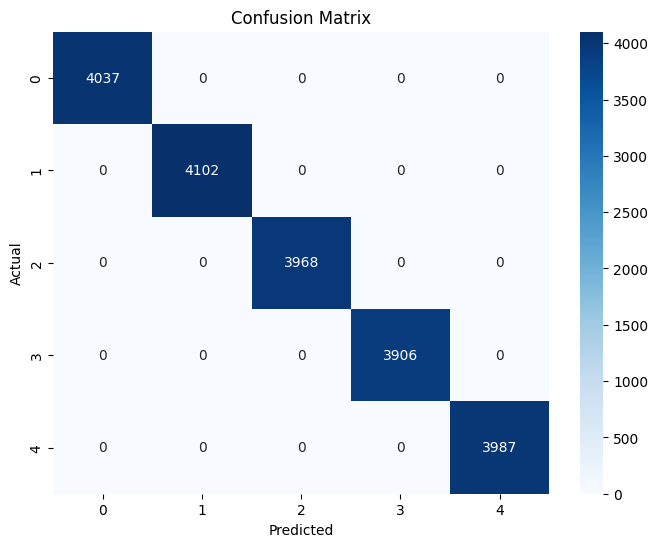

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                        Feature  Importance
6                Monthly_Salary    0.576218
3                     Job_Title    0.128995
15  Employee_Satisfaction_Score    0.033524
13               Training_Hours    0.031014
8              Projects_Handled    0.028360
2                           Age    0.027575
7           Work_Hours_Per_Week    0.026341
9                Overtime_Hours    0.026218
12                    Team_Size    0.023520
10                    Sick_Days    0.021284
4              Years_At_Company    0.019331
0                    Department    0.018853
11        Remote_Work_Frequency    0.013643
5               Education_Level    0.009545
14                   Promotions    0.008912
1                        Gender    0.006669


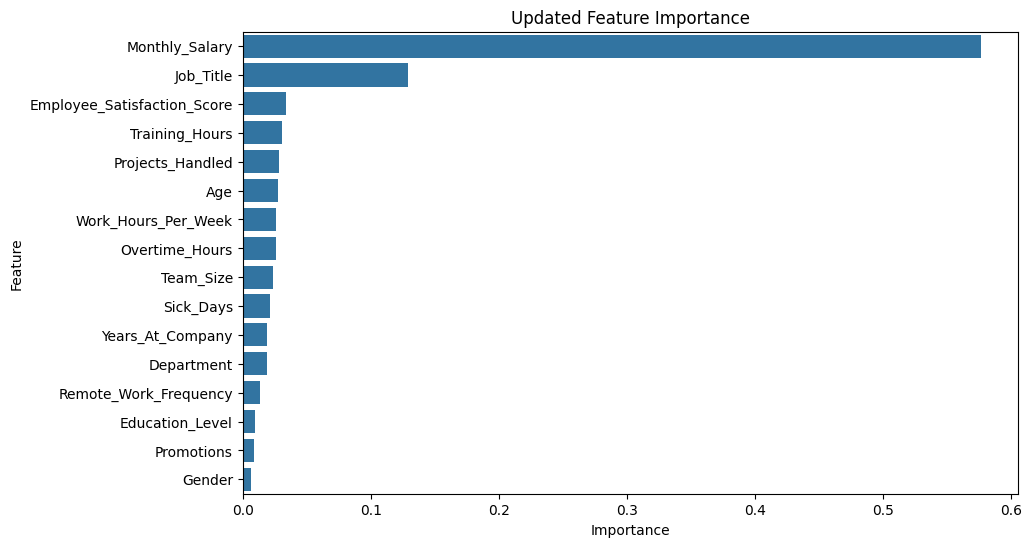

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Updated Feature Importance")
plt.show()

## Final Conclusion

The Random Forest model achieved perfect accuracy on the dataset.

EDA and feature importance analysis revealed that Monthly Salary and Job Title were the most influential variables affecting employee performance.

The dataset appeared highly balanced and potentially synthetic/rule-based, which may explain the near-perfect model performance.